# Resultados — Polaris

Avaliação da recuperação de contexto (RAG) do `LocalRetriever` sobre a base de documentos do usuário (papers de Gassmann 1951, Russell 1991 e Shuey 1985), com Recall@k e um exemplo qualitativo de resposta com/sem RAG.

In [1]:
import json

import matplotlib.pyplot as plt

from polaris_core.config import ConfigStore
from polaris_core.factory import create_service
from polaris_core.models import AssistantRequest
from polaris_core.retrieval import LocalRetriever

## 1. Recall@k da recuperação

In [2]:
TEST_SET = [
    {"query": "Como a equação de Gassmann relaciona a substituição de fluido com o módulo de incompressibilidade da rocha?", "expected": "gassmann1951.pdf"},
    {"query": "Qual a velocidade elástica de um empacotamento de esferas com os poros preenchidos por líquido ou gás?", "expected": "gassmann1951.pdf"},
    {"query": "Como a porosidade afeta a elasticidade de um meio poroso segundo Gassmann?", "expected": "gassmann1951.pdf"},
    {"query": "Quais são os métodos comparados de inversão sísmica pós-empilhamento (poststack)?", "expected": "russel1991.pdf"},
    {"query": "Como extrair informação de impedância acústica a partir de dados sísmicos empilhados?", "expected": "russel1991.pdf"},
    {"query": "Qual a suposição do modelo convolucional usada na inversão sísmica de traço único?", "expected": "russel1991.pdf"},
    {"query": "Qual a simplificação proposta por Shuey para as equações de Zoeppritz?", "expected": "shuey1985.pdf"},
    {"query": "Como o coeficiente de reflexão varia com o ângulo de incidência em AVO?", "expected": "shuey1985.pdf"},
    {"query": "O que representa o termo de amplitude na incidência normal na equação de Shuey?", "expected": "shuey1985.pdf"},
]

retriever = LocalRetriever.from_user_docs()
print("Documentos carregados:", [d.name for d in retriever.documents])

Documentos carregados: ['gassmann1951.pdf', 'russel1991.pdf', 'shuey1985.pdf']


In [3]:
ks = [1, 3, 6]
hits = {k: 0 for k in ks}
rows = []

for case in TEST_SET:
    results = retriever.search(case["query"], top_k=6)
    retrieved_docs = [r.document_name for r in results]
    row = {"query": case["query"], "expected": case["expected"], "retrieved_order": retrieved_docs}
    for k in ks:
        hit = case["expected"] in retrieved_docs[:k]
        row[f"hit@{k}"] = hit
        if hit:
            hits[k] += 1
    rows.append(row)

n = len(TEST_SET)
summary = {f"recall@{k}": hits[k] / n for k in ks}
print(json.dumps(summary, indent=2))

{
  "recall@1": 0.4444444444444444,
  "recall@3": 0.7777777777777778,
  "recall@6": 1.0
}


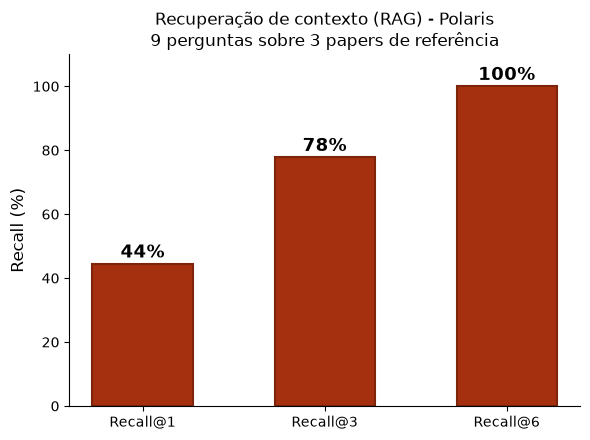

In [8]:
labels = ["Recall@1", "Recall@3", "Recall@6"]
values = [summary[f"recall@{k}"] * 100 for k in ks]

fig, ax = plt.subplots(figsize=(6, 4.5))
bars = ax.bar(labels, values, color="#a5300f", edgecolor="#7d240b", linewidth=1.5, width=0.55)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 2, f"{val:.0f}%", ha="center", fontsize=13, fontweight="bold")

ax.set_ylim(0, 110)
ax.set_ylabel("Recall (%)", fontsize=12)
ax.set_title("Recuperação de contexto (RAG) - Polaris\n9 perguntas sobre 3 papers de referência", fontsize=12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("recall_at_k.png", dpi=500)
plt.show()

## 2. Exemplo qualitativo — resposta com e sem RAG

Requer uma API key configurada (`polaris configure`). Faz uma chamada real ao provedor configurado.

In [5]:
QUESTION = "Segundo Shuey (1985), qual é a forma simplificada da equação de Zoeppritz e o que representa cada termo?"

cfg = ConfigStore().load()
api_key = cfg.api_key_for()

service_rag = create_service(model=cfg.model, api_key=api_key, model_provider=cfg.provider)
service_rag.retriever = retriever

service_no_rag = create_service(model=cfg.model, api_key=api_key, model_provider=cfg.provider)
service_no_rag.retriever = None

resp_rag = service_rag.ask(AssistantRequest(message=QUESTION, use_retrieval=True))
resp_no_rag = service_no_rag.ask(AssistantRequest(message=QUESTION, use_retrieval=False))

In [6]:
from IPython.display import HTML, display

display(HTML(f"<h4>Sem RAG</h4>{resp_no_rag.content}<hr><h4>Com RAG</h4>{resp_rag.content}"))